In [1]:
import os
import sys
import yaml
import numpy as np
import pandas as pd
import joblib
from joblib import Parallel, delayed
import time
import json

from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

from pathlib import Path
parent_dir = Path(os.getcwd()).parent
sys.path.append(str(parent_dir))

from libML.data_load_and_label_for_training import load_emg_data
from libML.models import choose_model
from libML.evaluation import compute_scores, plot_cv_scores, plot_labels
from libML.export import save_best_params, save_model
from libML.preprocessing_new import segment_aux_windows_new, notch_filter, passband_filter
from libML.feature_engineering import extract_window_features


In [ ]:
def load_model_and_scaler(model_name, dof_name, results_dir):
    """
    Load a saved model and its scaler from disk.
    
    Args:
        model_name (str): Name of the model (e.g., "LDA", "SVM")
        dof_name (str): Name of the degree of freedom (e.g., "wrist_flex_ext")
        model_dir (str): Directory where models are saved
    
    Returns:
        tuple: (model, scaler) - loaded model and scaler objects
    """
    try:
        model_path = os.path.join(results_dir, f"{model_name}/model_{dof_name}.joblib")
        scaler_path = r"C:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\results\scaler\scaler_standard.pkl" #os.path.join(model_dir, f"{model_name}/scaler_{dof_name}.joblib")
        
        # Load model
        model = joblib.load(model_path)
        print(f"Loaded model from: {model_path}")
        
        # Load scaler if it exists
        scaler = None
        if os.path.exists(scaler_path):
            scaler = joblib.load(scaler_path)
            print(f"Loaded scaler from: {scaler_path}")
        else:
            print(f"No scaler found at: {scaler_path}")
            
        return model, scaler
        
    except Exception as e:
        print(f"Error loading model or scaler for {dof_name}: {e}")
        return None, None

def measure_inference_time(model, scaler, sample_data, num_iterations=1000):
    """
    Measure inference time for a single prediction.
    
    Args:
        model: Loaded scikit-learn model
        scaler: Loaded scaler (or None)
        sample_data: Single sample for prediction (1D array)
        num_iterations (int): Number of iterations for timing
    
    Returns:
        dict: Timing results in milliseconds
    """
    # Ensure sample_data is 2D (samples, features)
    if len(sample_data.shape) == 1:
        sample_data = sample_data.reshape(1, -1)
    
    # Apply scaler if available
    if scaler is not None:
        sample_data = scaler.transform(sample_data)
    
    # Warm-up run
    _ = model.predict(sample_data)
    
    # Measure inference time
    start_time = time.perf_counter()
    for _ in range(num_iterations):
        _ = model.predict(sample_data)
    end_time = time.perf_counter()
    
    total_time_ms = (end_time - start_time) * 1000
    avg_time_ms = total_time_ms / num_iterations
    
    return {
        'total_time_ms': total_time_ms,
        'avg_time_ms': avg_time_ms,
        'num_iterations': num_iterations
    }

def run_single_inference(model, scaler, sample_data):
    """
    Run a single inference and return the prediction.
    
    Args:
        model: Loaded scikit-learn model
        scaler: Loaded scaler (or None)
        sample_data: Single sample for prediction
    
    Returns:
        prediction: Model prediction
    """
    # Ensure sample_data is 2D (samples, features)
    if len(sample_data.shape) == 1:
        sample_data = sample_data.reshape(1, -1)
    
    # Apply scaler if available
    if scaler is not None:
        sample_data = scaler.transform(sample_data)
    
    # Run prediction
    prediction = model.predict(sample_data)
    return prediction[0]  # Return single prediction

In [3]:
parent_dir = Path(os.getcwd()).parent
MODEL_DIR = os.path.join(parent_dir, "./results/models")  # Your model directory
MODEL_NAME = "RandomForest"  # e.g., "LDA", "SVM", "RandomForest"
DOF_NAME = "wrist_flex_ext"  # Your degree of freedom namZ

# Load model and scaler
model, scaler = load_model_and_scaler(MODEL_NAME, DOF_NAME, MODEL_DIR)

if model is None:
    print("Failed to load model")
    sys.exit(1)

# Create sample data (replace with your actual feature data)
# This should match the shape your model expects
sample_data = np.random.randn(1, 126)  # Example: 1 sample with 8 features

# Run single inference
print("\n--- Single Inference ---")
prediction = run_single_inference(model, scaler, sample_data)
print(f"Prediction: {prediction}")

# Measure inference time
print("\n--- Inference Timing ---")
timing_results = measure_inference_time(model, scaler, sample_data, num_iterations=1000)
    
print(f"Total time for {timing_results['num_iterations']} iterations: {timing_results['total_time_ms']:.2f} ms")
print(f"Average inference time: {timing_results['avg_time_ms']:.4f} ms")
print(f"Potential throughput: {1000/timing_results['avg_time_ms']:.0f} inferences/second")

Loaded model from: c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\./results/models\RandomForest/model_wrist_flex_ext.joblib
No scaler found at: C:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\results\scaler\scaler_standard.pkl

--- Single Inference ---
Prediction: 1

--- Inference Timing ---
Total time for 1000 iterations: 35759.24 ms
Average inference time: 35.7592 ms
Potential throughput: 28 inferences/second


### Prediction consistency analysis

In [4]:
import yaml
from pathlib import Path
parent_dir = Path(os.getcwd()).parent
sys.path.append(str(parent_dir))
CONFIG = yaml.safe_load(open(str(parent_dir / "config.yml")))
#TODO: Put all parameters in config file
# --- File/Directory Paths
PATHS = CONFIG.get('paths', {})
DATA_DIR = PATHS.get('raw_data_dir', './data/raw/')
PROCESSED_DATA_PATH = PATHS.get('processed_data_path', './data/processed/all_features.parquet')
MODEL_OUTPUT_DIR = PATHS.get('model_output_dir', './results/models/')
SCALER_OUTPUT_DIR = PATHS.get('scaler_output_dir', './results/scaler/')
BEST_PARAMS_OUTPUT_DIR = PATHS.get('best_params_output_dir', './results/params/')
FIG_OUTPUT_DIR = PATHS.get('fig_output_dir', './results/figures')
TIMING_OUTPUT_DIR = PATHS.get('timing_output_dir', './results/timing/')
SCALER_OUTPUT_DIR = PATHS.get('scaler_output_dir', './results/scaler/')

# --- Patient filters
FILTERS = CONFIG.get('filters', {})
SUBJECTS = FILTERS.get('subjects', "P005")
SESSIONS = FILTERS.get('sessions', "S002")
TASKS = FILTERS.get('tasks', "Default")
RUNS = FILTERS.get('runs', "001_eeg_up")

# --- Windowing & Feature Parameters
PROC = CONFIG.get('processing', {})
SAMPLE_RATE_HZ = PROC.get('sample_rate_hz', 2000)
WINDOW_SIZE_MS = PROC.get('window_size_ms', 200)
WINDOW_STEP_MS = PROC.get('window_step_ms', 50)
PREPROCESSING = PROC.get('preprocessing', True)

WINDOW_SIZE_SAMPLES = int(SAMPLE_RATE_HZ * (WINDOW_SIZE_MS / 1000.0))
WINDOW_STEP_SAMPLES = int(SAMPLE_RATE_HZ * (WINDOW_STEP_MS / 1000.0))

# --- Model & Training Parameters
MODELING = CONFIG.get('modeling', {})
DOF_LIST = MODELING.get('dof_list', []) # Default to empty list
MODEL_TYPE = MODELING.get('model_type', 'LDA')
ALL_HYPERPARAMS = MODELING.get('hyperparams', {})

RANDOM_STATE = MODELING.get('random_state', 42)
TEST_SIZE = MODELING.get('test_size', 0.15)
VAL_SIZE = MODELING.get('val_size', 0.15)

# Grid search
HYPERPARAMETER_SEARCH = MODELING.get('hyperparam_search', False)
NESTED_CV = MODELING.get('nested_cv', False)
ALL_PARAM_GRIDS = MODELING.get('param_grids', {})
NUM_TRIALS = MODELING.get('num_trials', 10)
N_SPLITS = MODELING.get('cv', 5)

In [5]:
DATA_DIR = os.path.join(parent_dir, DATA_DIR)
DATA_DIR

'c:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\./data/raw/'

In [6]:
def get_features(data_dict):
    # Get windows 
    X = data_dict["X"]
    y = data_dict["y"]
    windowed_df = segment_aux_windows_new(X, y)
    
    #breakpoint()
    # Apply preprocessing steps (filtering)
    preproc_df = notch_filter(windowed_df)
    preproc_df = passband_filter(preproc_df) 

    # Get features from windows
    # features_df contains all 6 channels with each feature --> 6*21 = 126 columns, named for example 0_AR4 --> channel id + _ + feature name
    # + 2 columns for label and window index so we have 128 columns    
    features_list = []
    for idx in range(len(preproc_df)):
        window_features = {}
        for ch in preproc_df.columns:
            if not(ch in [0,1,2,3,4,5]):
                continue
            signal_window = preproc_df.loc[idx, ch]
            #print(idx, ch)
            #print(signal_window)
            ch_features = extract_window_features(signal_window, fs=1000)
            
            # Prefix with channel name
            for feat_name, feat_val in ch_features.items():
                window_features[f"{ch}_{feat_name}"] = feat_val

        #preproc_df.keys()
        window_features['window_index'] = preproc_df.loc[idx, 'window_index']
        window_features['dof_1'] = preproc_df.loc[idx, 'dof_1_label']
        window_features['dof_2'] = preproc_df.loc[idx, 'dof_2_label']
        window_features['dof_3'] = preproc_df.loc[idx, 'dof_3_label']
        window_features['dof_4'] = preproc_df.loc[idx, 'dof_4_label']
        window_features['dof_5'] = preproc_df.loc[idx, 'dof_5_label']
        window_features['dof_6'] = preproc_df.loc[idx, 'dof_6_label']
        window_features['dof_7'] = preproc_df.loc[idx, 'dof_7_label']
        window_features['dof_8'] = preproc_df.loc[idx, 'dof_8_label']
        #window_features['dof_9'] = preproc_df.loc[idx, 'dof_9_label']
        #window_features['dof_10'] = preproc_df.loc[idx, 'dof_10_label']
        
        features_list.append(window_features)

    features_df = pd.DataFrame(features_list)
    #breakpoint()
    return features_df

def scale_features(processed_data, method='standard', save_path=None, return_dataframe=True):
    """
    Scale features and return scaled data with proper structure
    """
    # Handle input data
    if isinstance(processed_data, list):
        all_data = pd.concat(processed_data, ignore_index=True)
        was_list = True
    else:
        all_data = processed_data
        was_list = False
    
    # Identify columns
    label_cols = [col for col in all_data.columns if col.startswith('dof_')]
    meta_cols = [col for col in all_data.columns if col in ['window_index', 'label', 'subject_id', 'session_id']]
    feature_cols = [col for col in all_data.columns if col not in label_cols + meta_cols]
    
    X = all_data[feature_cols].values
    feature_names = feature_cols  # Keep track of feature names
    
    # Choose and fit scaler
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'robust':
        scaler = RobustScaler()
    elif method == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError(f"Unknown scaling method: {method}")
    
    X_scaled = scaler.fit_transform(X)
    
    # Save scaler
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        scaler_filename = f"scaler_{method}.pkl"
        scaler_filepath = os.path.join(save_path, scaler_filename)
        joblib.dump(scaler, scaler_filepath)
        
        # Also save feature names for reference
        feature_info = {
            'feature_names': feature_cols,
            'label_names': label_cols,
            'meta_names': meta_cols,
            'scaling_method': method
        }
        feature_info_path = os.path.join(save_path, f"feature_info_{method}.pkl")
        joblib.dump(feature_info, feature_info_path)
        print(f"Scaler and feature info saved to {save_path}")
    
    # Return appropriate format
    if return_dataframe:
        # Create new DataFrame with scaled features
        scaled_df = all_data.copy()
        scaled_df[feature_cols] = X_scaled
        
        if was_list:
            # Return list of DataFrames if input was list
            result = []
            start_idx = 0
            for df in processed_data:
                end_idx = start_idx + len(df)
                scaled_slice = scaled_df.iloc[start_idx:end_idx].reset_index(drop=True)
                result.append(scaled_slice)
                start_idx = end_idx
            return scaler, result
        else:
            return scaler, scaled_df
    else:
        return scaler, X_scaled

In [7]:
data_list = []
if os.path.exists(DATA_DIR):
    # Loads data from all the filters
    data_list = load_emg_data(DATA_DIR, subject=SUBJECTS, session=SESSIONS, task=TASKS, run=RUNS) # list of dict

# Get features for all data available
processed_data_list = []
for run in data_list:
    # Get features for 1 run
    print("Getting features ...")
    processed_data = get_features(run)
    processed_data_list.append(processed_data)
    print("Got features!")

print("Scaling features...")
scaler, scaled_data_list = scale_features(
    processed_data_list,
    method='standard',  # Choose: 'standard', 'robust', or 'minmax'
    save_path=SCALER_OUTPUT_DIR,
    return_dataframe=True
)

Starting data load with filters: {'subject': ['P005'], 'session': ['S002'], 'task': ['Default'], 'run': ['001_eeg_up']}
c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\./data/raw/sub-01\emg\sub-01_task-Cyl_acq-cometa_emg.edf
c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\./data/raw/sub-P005\ses-S002\emg\sub-P005_ses-S002_task-Default_run-001_eeg_up.xdf
c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\./data/raw/sub-P005\ses-S003\emg\sub-P005_ses-S003_task-Default_run-001_eeg_side.xdf
c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\./data/raw/sub-P005\ses-S004\emg\sub-P005_ses-S004_task-Default_run-001_eeg_down.xdf
c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\./data/raw/sub-P005\ses-S005\emg\sub-P005_ses-S005_task-Default_run-001_eeg.xdf
c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\./data/raw/sub-P005\ses-S006\emg\sub-P005_ses-S006_task-Default_run-001_eeg.xdf
c:\Users\willi\Desktop\BMI-Software\Signal Processing & 

In [49]:
scaled_data_list[0]["window_index"]

0        1311
1        1312
2        1313
3        1314
4        1315
        ...  
6362    17733
6363    17734
6364    17735
6365    17736
6366    17737
Name: window_index, Length: 6367, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
from itertools import groupby

def group_consecutive_windows(scaled_data_list):
    """Group windows that directly follow each other into separate dictionaries"""
    if not scaled_data_list:
        return []
    
    # Sort by window_index to ensure consecutive order
    sorted_data = sorted(scaled_data_list, key=lambda x: x["window_index"])

    # Group consecutive window indices
    groups = []
    current_group = []
    
    for i, window in enumerate(sorted_data):
        if not current_group:
            current_group.append(window)
        else:
            # Check if this window directly follows the previous one
            prev_index = current_group[-1]["window_index"]
            if window["window_index"] == prev_index + 1:
                current_group.append(window)
            else:
                # Break in sequence, start new group
                groups.append(current_group)
                current_group = [window]
    
    # Don't forget the last group
    if current_group:
        groups.append(current_group)
    
    return groups

# Usage
consecutive_groups = group_consecutive_windows(scaled_data_list)
print(f"Found {len(consecutive_groups)} groups of consecutive windows")

for i, group in enumerate(consecutive_groups):
    print(f"Group {i}: Windows {group[0]['window_index']} to {group[-1]['window_index']} "
          f"({len(group)} consecutive windows)")

0
         0_MAV     0_VAR     0_RMS     0_SSC      0_ZC      0_WL     0_AR1  \
0    -0.722005 -0.448148 -0.729513  1.357714 -0.960545 -0.710329  0.093913   
1    -0.729449 -0.446406 -0.722640  0.722178 -0.374854 -0.692464  0.093660   
2    -0.806038 -0.466037 -0.780729 -0.231127 -0.082008 -0.746598  0.089405   
3    -0.795626 -0.463139 -0.769895 -0.072243 -0.374854 -0.745661  0.115306   
4    -0.897609 -0.485092 -0.838307 -0.072243  0.210838 -0.758991  0.085130   
...        ...       ...       ...       ...       ...       ...       ...   
6362  0.531189  0.496376  0.949308 -1.978852 -1.253391 -0.378432  0.183203   
6363 -0.456765 -0.313028 -0.380180 -0.072243 -0.228431 -0.640652  0.152071   
6364 -0.633581 -0.417202 -0.645127 -0.231127 -1.106968 -0.650157  0.108593   
6365 -0.667666 -0.414131 -0.636962 -0.231127 -0.521277 -0.646189  0.099308   
6366 -0.622720 -0.395775 -0.587793  0.086641 -0.667700 -0.635172  0.106576   

         0_AR2     0_AR3     0_AR4  ...   5_WTMAV  window_ind

### Timing analysis

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os

DOF_NAMES = ["wrist_flex_ext", "thumb_flex_ext", "thumb_abd_add", 
             "index_flex_ext", "middle_flex_ext", "ring_flex_ext", "pinky_flex_ext"] # "wrist_pro_sup",
MODEL_NAMES = ["RandomForest", "LDA", "SVM", "DecisionTree", "GaussianNB"]

# Create sample data (adjust shape to match your features)
sample_data = np.random.randn(1, 126)

# Dictionary to store all timing results
all_timing_results = {}

for model_name in MODEL_NAMES:
    print(f"\n{'='*60}")
    print(f"TESTING MODEL: {model_name}")
    print(f"{'='*60}")
    
    model_times = {}
    
    for dof_name in DOF_NAMES:
        print(f"  DOF: {dof_name}")
        
        model, scaler = load_model_and_scaler(model_name, dof_name, MODEL_DIR)
        
        if model is not None:
            # Single inference
            prediction = run_single_inference(model, scaler, sample_data)
            print(f"    Single prediction: {prediction}")
            
            # Timing
            timing_results = measure_inference_time(model, scaler, sample_data, 1000)
            avg_time_ms = timing_results['avg_time_ms']
            print(f"    Avg inference time: {avg_time_ms:.4f} ms")
            
            model_times[dof_name] = {
                'avg_time_ms': avg_time_ms,
                'std_time_ms': timing_results.get('std_time_ms', 0),
                'min_time_ms': timing_results.get('min_time_ms', 0),
                'max_time_ms': timing_results.get('max_time_ms', 0),
                'prediction': prediction
            }
        else:
            print(f"    ⚠️  Model not found for {dof_name}")
            model_times[dof_name] = None
    
    # Calculate average across all DOFs for this model
    valid_times = [t['avg_time_ms'] for t in model_times.values() if t is not None]
    if valid_times:
        avg_across_dofs = np.mean(valid_times)
        std_across_dofs = np.std(valid_times)
    else:
        avg_across_dofs = np.nan
        std_across_dofs = np.nan
    
    all_timing_results[model_name] = {
        'per_dof_times': model_times,
        'avg_across_dofs': avg_across_dofs,
        'std_across_dofs': std_across_dofs,
        'n_valid_dofs': len(valid_times)
    }
    
    print(f"  → Average across all DOFs: {avg_across_dofs:.4f} ± {std_across_dofs:.4f} ms")




TESTING MODEL: RandomForest
  DOF: wrist_flex_ext
Loaded model from: c:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\./results/models\RandomForest/model_wrist_flex_ext.joblib
No scaler found at: c:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\./results/models\RandomForest/scaler_wrist_flex_ext.joblib
    Single prediction: 1
    Avg inference time: 11.2924 ms
  DOF: thumb_flex_ext
Loaded model from: c:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\./results/models\RandomForest/model_thumb_flex_ext.joblib
No scaler found at: c:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\./results/models\RandomForest/scaler_thumb_flex_ext.joblib
    Single prediction: 1
    Avg inference time: 11.0149 ms
  DOF: thumb_abd_add
Loaded model from: c:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\./results/models\RandomForest/model_thumb_abd_add.joblib
No scaler found at: c:\Users\miski\Desktop\Neuro-X\N-


GENERATING TIMING ANALYSIS PLOTS

1. Average Inference Time per Model


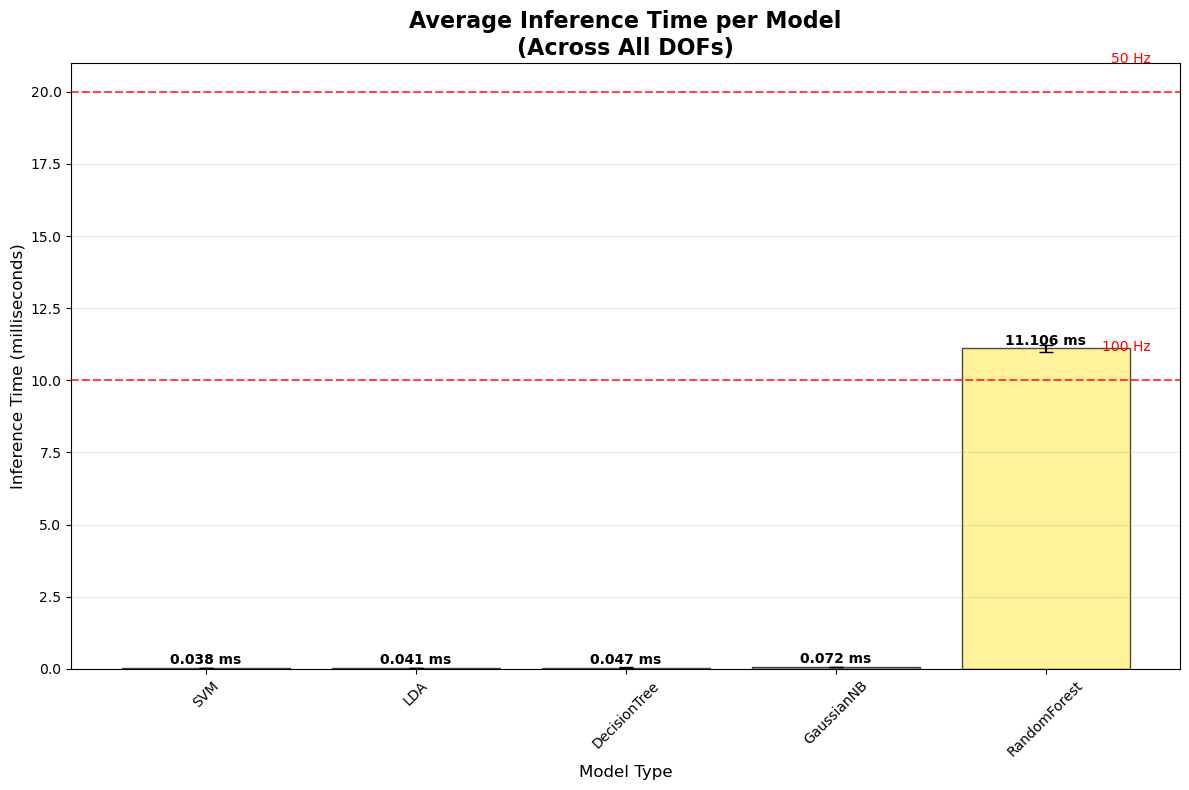


2. Per-DOF Inference Time Distribution


C:\Users\miski\AppData\Local\Temp\ipykernel_33664\2073832694.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(plot_data, labels=model_names, patch_artist=True)


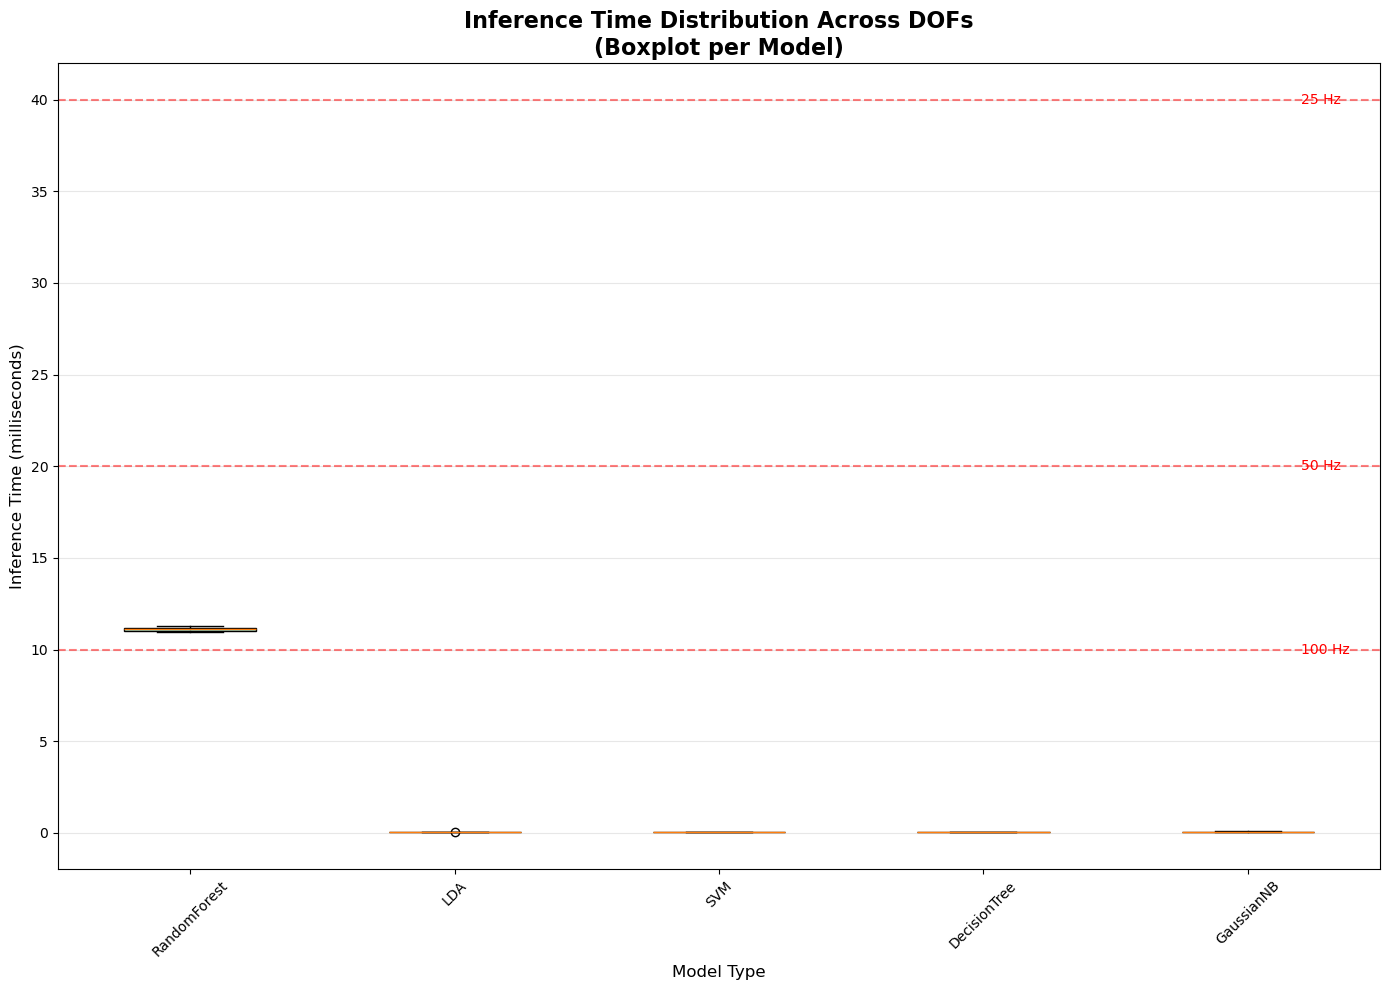


3. Inference Time Heatmap


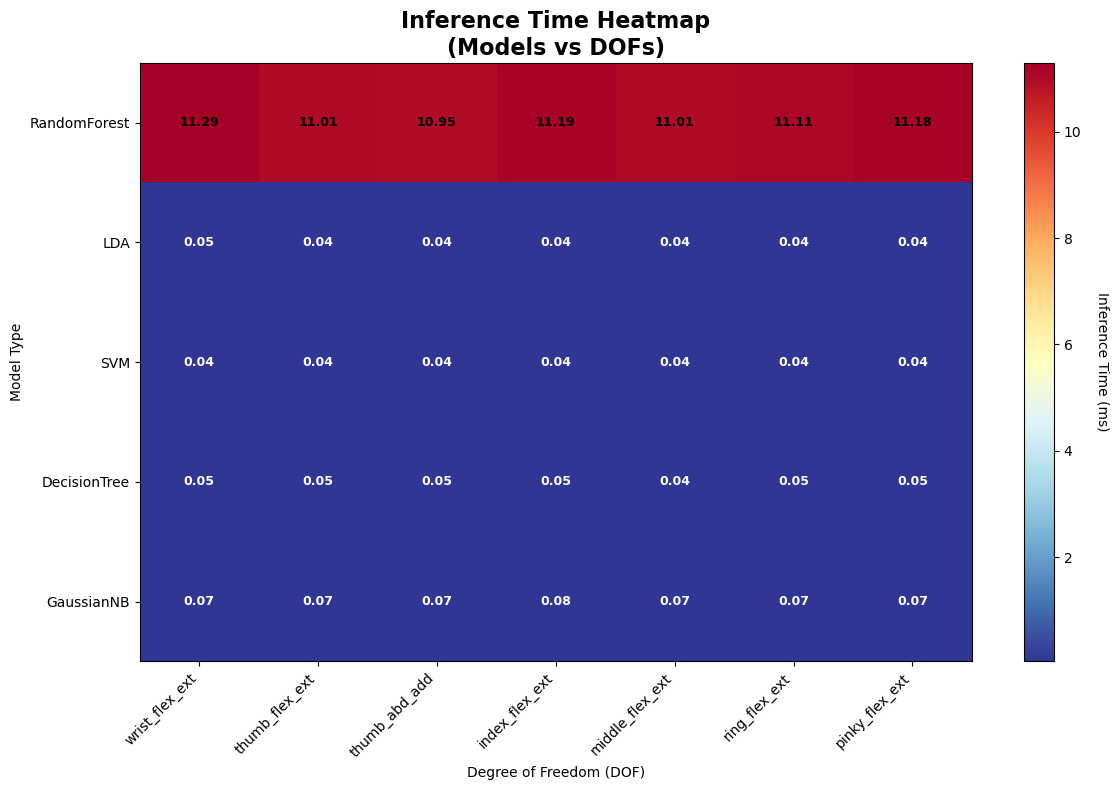


4. Real-Time Capability Assessment


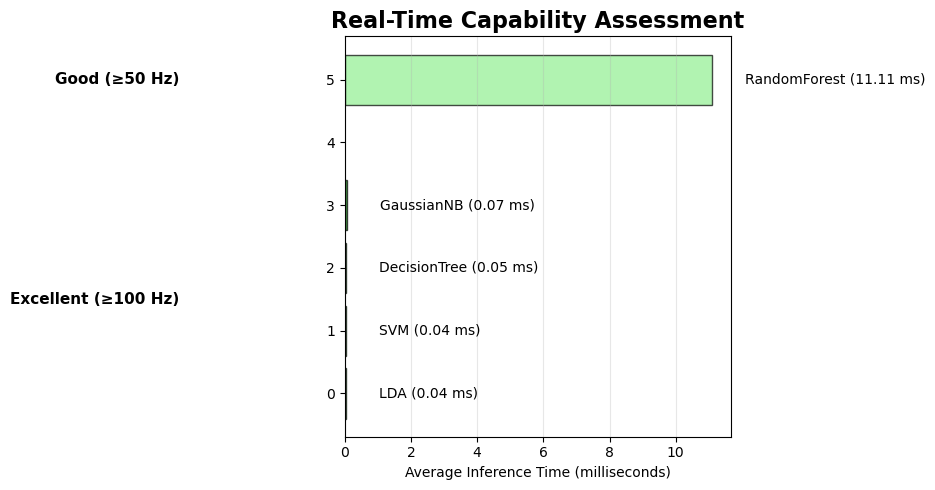


SUMMARY TABLE
       Model Avg Time (ms) Std (ms)  Valid DOFs Max Freq (Hz)
         SVM         0.038    0.001           7       26189.7
         LDA         0.041    0.003           7       24674.3
DecisionTree         0.047    0.002           7       21442.3
  GaussianNB         0.072    0.002           7       13804.5
RandomForest        11.106    0.113           7          90.0


In [27]:
# Plot 1: Average inference time per model (across all DOFs)
def plot_model_comparison_barchart(timing_results):
    """Plot average inference time for each model across all DOFs"""
    models = []
    avg_times = []
    std_times = []
    
    for model_name, model_data in timing_results.items():
        if not np.isnan(model_data['avg_across_dofs']):
            models.append(model_name)
            avg_times.append(model_data['avg_across_dofs'])
            std_times.append(model_data['std_across_dofs'])
    
    # Sort by average time (fastest to slowest)
    sorted_indices = np.argsort(avg_times)
    models = [models[i] for i in sorted_indices]
    avg_times = [avg_times[i] for i in sorted_indices]
    std_times = [std_times[i] for i in sorted_indices]
    
    plt.figure(figsize=(12, 8))
    bars = plt.bar(models, avg_times, yerr=std_times, capsize=5, 
                   color=plt.cm.Set3(np.linspace(0, 1, len(models))),
                   alpha=0.7, edgecolor='black')
    
    plt.title('Average Inference Time per Model\n(Across All DOFs)', fontsize=16, fontweight='bold')
    plt.ylabel('Inference Time (milliseconds)', fontsize=12)
    plt.xlabel('Model Type', fontsize=12)
    
    # Add value labels on bars
    for bar, value in zip(bars, avg_times):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f} ms', ha='center', va='bottom', fontweight='bold')
    
    # Add real-time capability reference lines
    real_time_limits = {
        '100 Hz': 10,
        '50 Hz': 20,
    }
    
    for label, limit in real_time_limits.items():
        plt.axhline(y=limit, color='red', linestyle='--', alpha=0.7)
        plt.text(len(models) - 0.5, limit + 1, label, 
                fontsize=10, color='red', ha='right')
    
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return models, avg_times

# Plot 2: Detailed per-DOF comparison
def plot_per_dof_comparison(timing_results):
    """Plot inference times for each DOF across all models"""
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Prepare data for box plot
    plot_data = []
    model_names = []
    
    for model_name, model_data in timing_results.items():
        if not np.isnan(model_data['avg_across_dofs']):
            dof_times = [dof_data['avg_time_ms'] for dof_data in model_data['per_dof_times'].values() 
                        if dof_data is not None]
            if dof_times:
                plot_data.append(dof_times)
                model_names.append(model_name)
    
    # Create box plot
    box_plot = ax.boxplot(plot_data, labels=model_names, patch_artist=True)
    
    # Color the boxes
    colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    plt.title('Inference Time Distribution Across DOFs\n(Boxplot per Model)', 
              fontsize=16, fontweight='bold')
    plt.ylabel('Inference Time (milliseconds)', fontsize=12)
    plt.xlabel('Model Type', fontsize=12)
    
    # Add real-time reference lines
    for limit, label in [(10, '100 Hz'), (20, '50 Hz'), (40, '25 Hz')]:
        ax.axhline(y=limit, color='red', linestyle='--', alpha=0.5)
        ax.text(len(model_names) + 0.2, limit, label, 
                va='center', ha='left', color='red', fontsize=10)
    
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot 3: Heatmap of inference times
def plot_inference_heatmap(timing_results):
    """Create a heatmap of inference times for each model and DOF"""
    # Create data matrix
    model_names = []
    dof_names = DOF_NAMES
    time_matrix = []
    
    for model_name, model_data in timing_results.items():
        if not np.isnan(model_data['avg_across_dofs']):
            model_names.append(model_name)
            row_times = []
            for dof_name in dof_names:
                dof_data = model_data['per_dof_times'].get(dof_name)
                if dof_data is not None:
                    row_times.append(dof_data['avg_time_ms'])
                else:
                    row_times.append(np.nan)
            time_matrix.append(row_times)
    
    time_matrix = np.array(time_matrix)
    
    # Create heatmap
    plt.figure(figsize=(12, 8))
    im = plt.imshow(time_matrix, cmap='RdYlBu_r', aspect='auto')
    
    # Add labels
    plt.xticks(range(len(dof_names)), dof_names, rotation=45, ha='right')
    plt.yticks(range(len(model_names)), model_names)
    
    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Inference Time (ms)', rotation=270, labelpad=20)
    
    # Add text annotations
    for i in range(len(model_names)):
        for j in range(len(dof_names)):
            if not np.isnan(time_matrix[i, j]):
                plt.text(j, i, f'{time_matrix[i, j]:.2f}', 
                        ha='center', va='center', fontsize=9, 
                        fontweight='bold', color='black' if time_matrix[i, j] > np.nanmean(time_matrix) else 'white')
    
    plt.title('Inference Time Heatmap\n(Models vs DOFs)', fontsize=16, fontweight='bold')
    plt.xlabel('Degree of Freedom (DOF)')
    plt.ylabel('Model Type')
    plt.tight_layout()
    plt.show()

# Plot 4: Real-time capability assessment
def plot_real_time_capability(timing_results):
    """Plot models categorized by real-time capability"""
    categories = {
        'Excellent (≥100 Hz)': [],
        'Good (≥50 Hz)': [],
        'Moderate (≥25 Hz)': [],
        'Slow (≥10 Hz)': [],
        'Not Real-time (<10 Hz)': []
    }
    
    for model_name, model_data in timing_results.items():
        avg_time = model_data['avg_across_dofs']
        if np.isnan(avg_time):
            continue
            
        if avg_time <= 10:
            categories['Excellent (≥100 Hz)'].append((model_name, avg_time))
        elif avg_time <= 20:
            categories['Good (≥50 Hz)'].append((model_name, avg_time))
        elif avg_time <= 40:
            categories['Moderate (≥25 Hz)'].append((model_name, avg_time))
        elif avg_time <= 100:
            categories['Slow (≥10 Hz)'].append((model_name, avg_time))
        else:
            categories['Not Real-time (<10 Hz)'].append((model_name, avg_time))
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    y_pos = 0
    colors = ['green', 'lightgreen', 'yellow', 'orange', 'red']
    
    for i, (category, models) in enumerate(categories.items()):
        if models:
            model_names = [m[0] for m in models]
            avg_times = [m[1] for m in models]
            
            bars = ax.barh([y_pos + j for j in range(len(models))], avg_times, 
                          color=colors[i], alpha=0.7, edgecolor='black')
            
            # Add labels
            for j, (bar, model_name, time_val) in enumerate(zip(bars, model_names, avg_times)):
                ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                       f'{model_name} ({time_val:.2f} ms)', 
                       va='center', ha='left', fontsize=10)
            
            y_pos += len(models) + 1
    
    ax.set_xlabel('Average Inference Time (milliseconds)')
    ax.set_title('Real-Time Capability Assessment', fontsize=16, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add category labels
    y_pos = 0
    for i, (category, models) in enumerate(categories.items()):
        if models:
            ax.text(-5, y_pos + len(models)/2 - 0.5, category, 
                   ha='right', va='center', fontweight='bold', fontsize=11)
            y_pos += len(models) + 1
    
    plt.tight_layout()
    plt.show()

# Generate all plots
print("\n" + "="*60)
print("GENERATING TIMING ANALYSIS PLOTS")
print("="*60)

# Plot 1: Model comparison barchart
print("\n1. Average Inference Time per Model")
models_sorted, avg_times_sorted = plot_model_comparison_barchart(all_timing_results)

# Plot 2: Per-DOF comparison
print("\n2. Per-DOF Inference Time Distribution")
plot_per_dof_comparison(all_timing_results)

# Plot 3: Heatmap
print("\n3. Inference Time Heatmap")
plot_inference_heatmap(all_timing_results)

# Plot 4: Real-time capability
print("\n4. Real-Time Capability Assessment")
plot_real_time_capability(all_timing_results)

# Print summary table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
summary_data = []
for model_name in models_sorted:
    model_data = all_timing_results[model_name]
    summary_data.append({
        'Model': model_name,
        'Avg Time (ms)': f"{model_data['avg_across_dofs']:.3f}",
        'Std (ms)': f"{model_data['std_across_dofs']:.3f}",
        'Valid DOFs': model_data['n_valid_dofs'],
        'Max Freq (Hz)': f"{1000/model_data['avg_across_dofs']:.1f}" if model_data['avg_across_dofs'] > 0 else 'N/A'
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

In [28]:
# # For testing multiple models
# DOF_NAMES = ["wrist_flex_ext", "wrist_pro_sup", "thumb_flex_ext", "thumb_abd_add", 
#              "index_flex_ext", "middle_flex_ext", "ring_flex_ext", "pinky_flex_ext"]  # Your DOF names
# MODEL_NAMES = ["RandomForest", "LDA", "SVM", "DecisionTree", "GaussianNB"]  # Your model names "LDA", "SVM", "RandomForest"

# # Create sample data (adjust shape to match your features)
# sample_data = np.random.randn(1, 126)

# avg_inference_times_per_model = {}

# for model_name in MODEL_NAMES:
#     for dof_name in DOF_NAMES:
#         print(f"\n{'='*50}")
#         print(f"Testing: {model_name} - {dof_name}")
#         print(f"{'='*50}")
        
#         model, scaler = load_model_and_scaler(model_name, dof_name, MODEL_DIR)
        
#         if model is not None:
#             # Single inference
#             prediction = run_single_inference(model, scaler, sample_data)
#             print(f"Single prediction: {prediction}")
            
#             # Timing
#             timing_results = measure_inference_time(model, scaler, sample_data, 1000)
#             print(f"Avg inference time: {timing_results['avg_time_ms']:.4f} ms")

In [30]:
import matplotlib.pyplot as plt
def plot_true_vs_predicted(y_true, y_pred, title='True vs Predicted Labels'):
    """
    Plots true labels vs predicted labels as a function of sample index.
    
    Args:
        y_true: array of true labels
        y_pred: array of predicted labels
        title: plot title
    """
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(y_pred, label='Predicted Labels', alpha=0.3, linewidth=1.5)
    ax.plot(y_true, label='True Labels', alpha=0.3, linewidth=1.5)
    
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Class Label')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [10]:
processed_data_list[0]

,0_MAV,0_VAR,0_RMS,0_SSC,0_ZC,0_WL,0_AR1,0_AR2,0_AR3,0_AR4,...,5_WTMAV,window_index,dof_1,dof_2,dof_3,dof_4,dof_5,dof_6,dof_7,dof_8
0,13.547142,242.876708,15.593333,64,20,1098.903888,-0.435450,-0.996483,0.227492,1.332920,...,2.608254,1311,0,0,0,0,0,0,1,2
1,13.483208,244.578364,15.669353,60,24,1118.390600,-0.438061,-0.979283,0.235713,1.333157,...,3.008170,1312,0,0,0,0,0,0,1,2
2,12.825445,225.408134,15.026902,54,26,1059.344299,-0.481988,-1.030971,0.270133,1.374951,...,3.448153,1313,0,0,0,0,0,0,1,2
3,12.914870,228.237843,15.146722,55,24,1060.365984,-0.214562,-0.809058,0.036779,1.124863,...,2.912854,1314,0,0,0,0,0,0,1,2
4,12.039009,206.800978,14.390108,55,28,1045.826165,-0.526134,-1.062076,0.310456,1.416841,...,2.832098,1315,0,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362,24.309867,1165.202822,34.160600,43,18,1460.919627,0.486477,-0.297105,-0.567475,0.462839,...,2.052275,17733,1,1,1,1,1,0,0,1
6363,15.825080,374.821464,19.456861,55,25,1174.904607,0.165038,-0.487762,-0.282357,0.761308,...,2.192261,17734,1,1,1,1,1,0,0,1
6364,14.306551,273.095279,16.526616,54,19,1164.536811,-0.283871,-0.823310,0.110981,1.179617,...,2.379367,17735,1,1,1,1,1,0,0,1
6365,14.013814,276.094665,16.616928,54,23,1168.864969,-0.379740,-0.903815,0.194756,1.261468,...,2.293502,17736,1,1,1,1,1,0,0,1


In [15]:
def load_model_and_scaler(model_name, dof_name, results_dir, X_train=None):
    """
    Load a saved model and its scaler from disk.
    If scaler doesn't exist, fit one on X_train.
    
    Args:
        model_name (str): Name of the model (e.g., "LDA", "SVM")
        dof_name (str): Name of the degree of freedom (e.g., "wrist_flex_ext")
        results_dir (str): Base results directory
        X_train (array, optional): Training data to fit scaler if one doesn't exist
    
    Returns:
        tuple: (model, scaler) - loaded model and scaler objects
    """
    try:
        model_path = os.path.join(results_dir, f"models/{model_name}/model_{dof_name}.joblib")
        scaler_path = os.path.join(results_dir, f"scaler/{model_name}/scaler_{dof_name}.joblib")
        
        # Load model
        model = joblib.load(model_path)
        print(f"Loaded model from: {model_path}")
        
        # Load or create scaler
        scaler = None
        if os.path.exists(scaler_path):
            scaler = joblib.load(scaler_path)
            print(f"Loaded scaler from: {scaler_path}")
        else:
            print(f"No scaler found at: {scaler_path}")
            if X_train is not None:
                print(f"Fitting StandardScaler on training data...")
                scaler = StandardScaler()
                scaler.fit(X_train)
                print(f"Scaler fitted successfully")
            else:
                print(f"Warning: No scaler available and no training data provided")
            
        return model, scaler
        
    except Exception as e:
        print(f"Error loading model or scaler for {dof_name}: {e}")
        return None, None

In [22]:
def run_inference(model, scaler, X_feat):
    """
    Run inference on features.
    
    Args:
        model: Loaded scikit-learn model
        scaler: Loaded scaler (or None)
        X_feat: Feature data (2D array or DataFrame)
    
    Returns:
        y_pred: Model predictions
    """
    # Convert DataFrame to array if needed
    if isinstance(X_feat, pd.DataFrame):
        X_feat = X_feat.values
    
    # Ensure 2D
    if len(X_feat.shape) == 1:
        X_feat = X_feat.reshape(-1, 1)
    
    # Apply scaler if available
    if scaler is not None:
        X_feat = scaler.transform(X_feat)
    
    # Run prediction
    y_pred = model.predict(X_feat)
    
    return y_pred

c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with fea

Loaded model from: ../results\models/RandomForest/model_wrist_flex_ext.joblib
No scaler found at: ../results\scaler/RandomForest/scaler_wrist_flex_ext.joblib
Fitting StandardScaler on training data...
Scaler fitted successfully


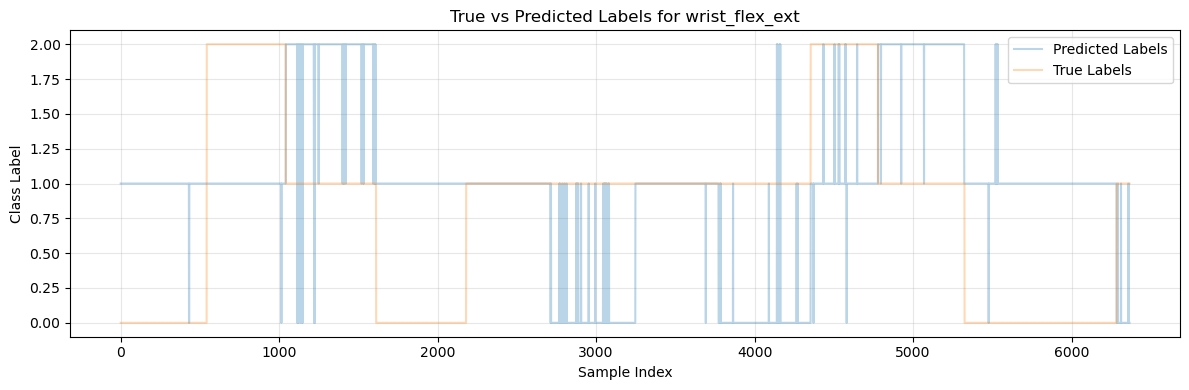

Error loading model or scaler for wrist_pro_sup: [Errno 2] No such file or directory: '../results\\models/RandomForest/model_wrist_pro_sup.joblib'
Error. No model.


c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with fea

Loaded model from: ../results\models/RandomForest/model_thumb_flex_ext.joblib
No scaler found at: ../results\scaler/RandomForest/scaler_thumb_flex_ext.joblib
Fitting StandardScaler on training data...
Scaler fitted successfully


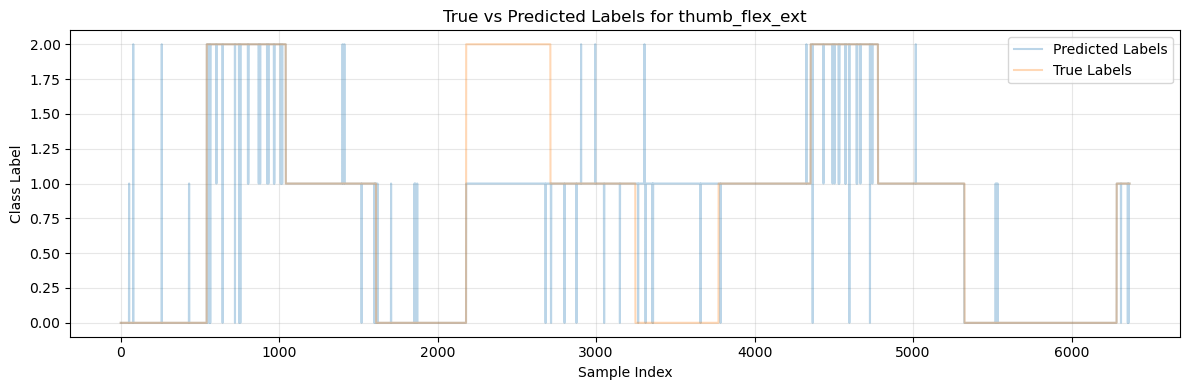

c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with fea

Loaded model from: ../results\models/RandomForest/model_thumb_abd_add.joblib
No scaler found at: ../results\scaler/RandomForest/scaler_thumb_abd_add.joblib
Fitting StandardScaler on training data...
Scaler fitted successfully


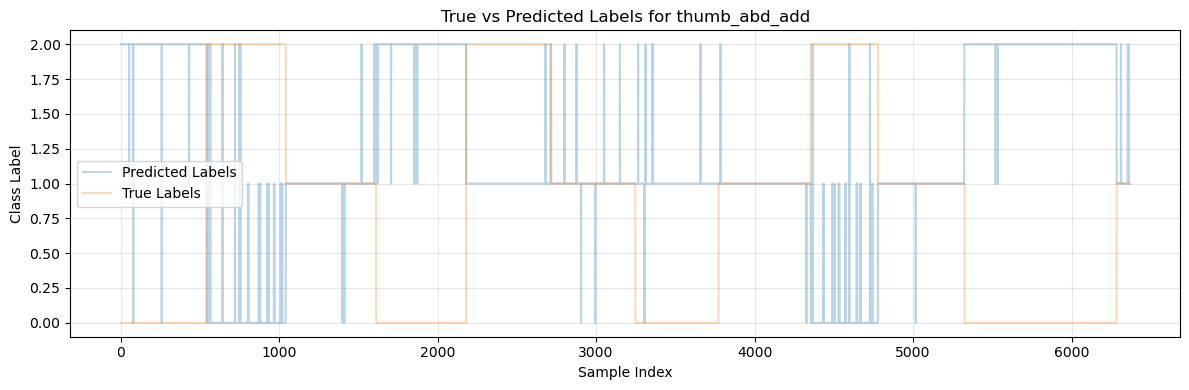

c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with fea

Loaded model from: ../results\models/RandomForest/model_index_flex_ext.joblib
No scaler found at: ../results\scaler/RandomForest/scaler_index_flex_ext.joblib
Fitting StandardScaler on training data...
Scaler fitted successfully


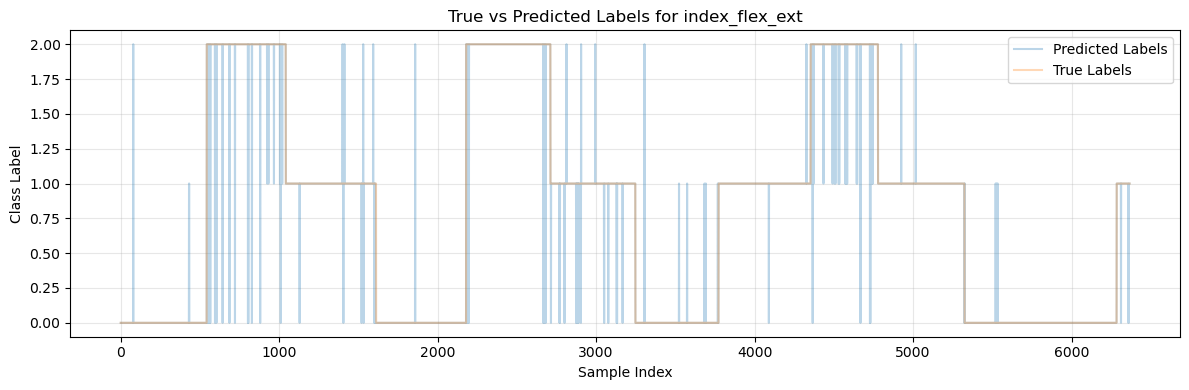

c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with fea

Loaded model from: ../results\models/RandomForest/model_middle_flex_ext.joblib
No scaler found at: ../results\scaler/RandomForest/scaler_middle_flex_ext.joblib
Fitting StandardScaler on training data...
Scaler fitted successfully


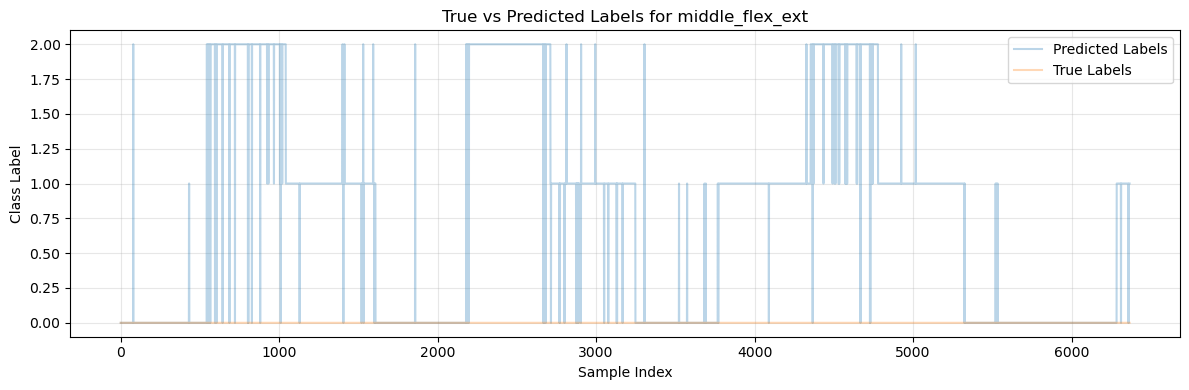

c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with fea

Loaded model from: ../results\models/RandomForest/model_ring_flex_ext.joblib
No scaler found at: ../results\scaler/RandomForest/scaler_ring_flex_ext.joblib
Fitting StandardScaler on training data...
Scaler fitted successfully


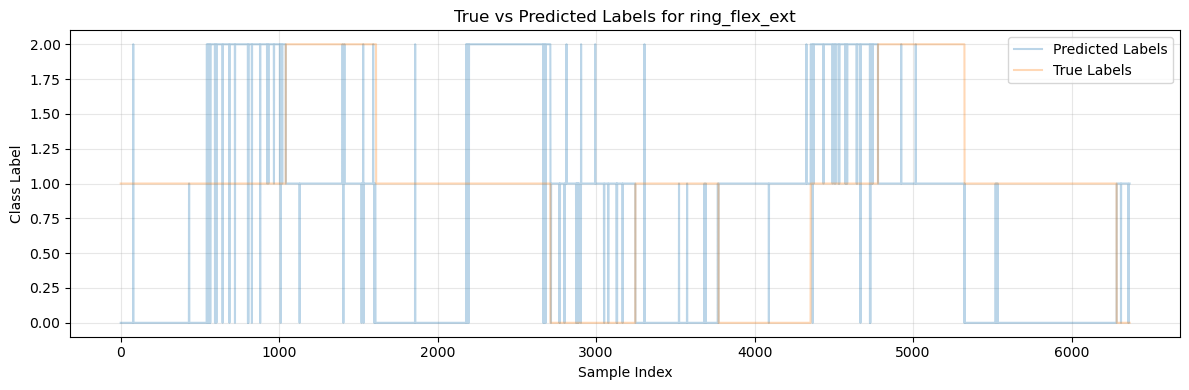

c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\willi\miniconda3\envs\ML\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with fea

Loaded model from: ../results\models/RandomForest/model_pinky_flex_ext.joblib
No scaler found at: ../results\scaler/RandomForest/scaler_pinky_flex_ext.joblib
Fitting StandardScaler on training data...
Scaler fitted successfully


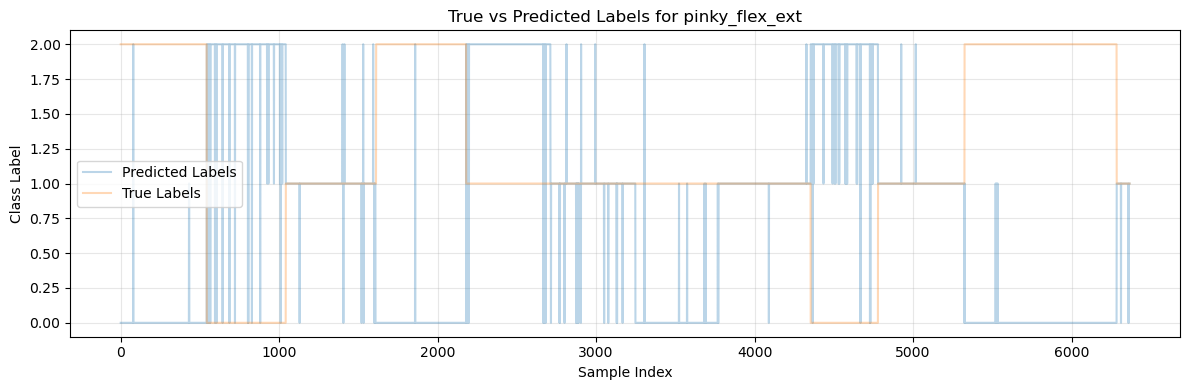

In [34]:
results_dir = "../results"
model_name = "RandomForest"

X_feat = processed_data_list[0].copy().drop(columns=["window_index", "dof_1", "dof_2", "dof_3", "dof_4", "dof_5", "dof_6", "dof_7", "dof_8"])

for i in range(len(DOF_LIST)):
    try:
        dof_name = DOF_LIST[i]
        dof_id = f"dof_{i+1}"
        model, scaler = load_model_and_scaler(model_name, dof_name, results_dir, X_feat)

        y_pred = run_inference(model, scaler, X_feat)
        y_true = processed_data_list[0][dof_id].values

        plot_true_vs_predicted(y_true, y_pred, title=f'True vs Predicted Labels for {dof_name}')
    except:
        print("Error. No model.")